In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

D:\Anaconda\envs\AI\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
img_height = 128
img_width = 128
batch_size = 32

In [ ]:
# train_datagen = ImageDataGenerator(
#     rescale=1./255,
# )

# val_datagen = ImageDataGenerator(
#     rescale=1./255
# )

In [7]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit/val",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 5600 files belonging to 8 classes.
Found 1600 files belonging to 8 classes.


In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

val_data = val_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [17]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu",
                           input_shape=(128,128,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(train_data.element_spec[1].shape[-1], activation="softmax")
])

In [18]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=5,
        min_lr=1e-6
    )
]

In [22]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 386ms/step - accuracy: 0.4712 - loss: 1.6726 - val_accuracy: 0.1894 - val_loss: 5.1732 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 378ms/step - accuracy: 0.6007 - loss: 1.2178 - val_accuracy: 0.3756 - val_loss: 1.7298 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 66s 376ms/step - accuracy: 0.6607 - loss: 1.0171 - val_accuracy: 0.5931 - val_loss: 1.1884 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 69s 396ms/step - accuracy: 0.6996 - loss: 0.8963 - val_accuracy: 0.5594 - val_loss: 1.3817 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 443ms/step - accuracy: 0.7271 - loss: 0.8114 - val_accuracy: 0.7237 - val_loss: 0.7771 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 74s 422ms/step - accuracy: 0.7645 - loss: 0.7089 - val_accuracy: 0.6037 - val_loss: 1.5113 - learning_rate: 0.0010
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 410ms/step - accuracy: 0.7

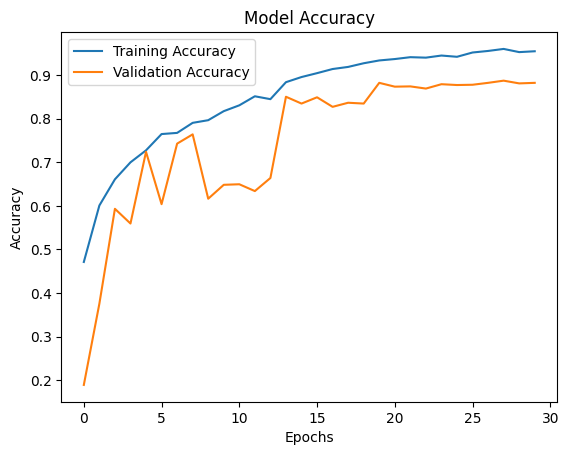

In [23]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

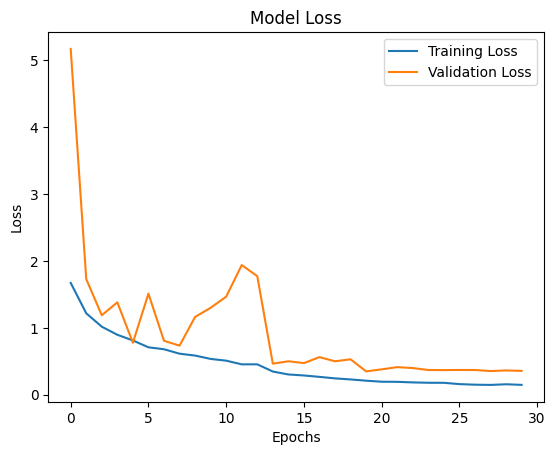

In [24]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [25]:
model.save("CNN_MODEL_FRUIT_CLASSIFICATION.h5")

In [26]:
import json
with open("Trained_History_PROJECT_FRUIT.json",'w') as f:
    json.dump(history.history,f)

In [ ]:
# test_datagen = ImageDataGenerator(rescale=1./255)

In [5]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'fruit/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(128, 128),
    batch_size=8,
    shuffle=True
)

test_data = test_data.map(lambda x, y: (x/255.0, y))

val_loss, val_acc = model.evaluate(test_data)
val_acc = val_acc *100
print(f"Test Accuracy: {val_acc:.2f}")

Found 800 files belonging to 8 classes.
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8700 - loss: 0.3715
Test Accuracy: 87.00


In [4]:
model = tf.keras.models.load_model("CNN_MODEL_FRUIT_CLASSIFICATION.h5")

In [8]:
class_names = train_data.class_names

In [11]:
# Evaluate directly on dataset
test_loss, test_accuracy = model.evaluate(test_data, verbose=0)

print('=' * 55)
print('  FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

# Collect all true labels
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_data])

# Predict probabilities for all images
y_prob = model.predict(test_data, verbose=0)

# Predicted labels
y_pred = np.argmax(y_prob, axis=1)

idx = 1
print(f'\nExample Prediction (Test image {idx}):')
print(f'  True label  : {y_true[idx]} ({class_names[y_true[idx]]})')
print(f'  Predicted   : {y_pred[idx]} ({class_names[y_pred[idx]]})')
print(f'  Confidence  : {y_prob[idx][y_pred[idx]] * 100:.1f}%')

  FINAL TEST SET RESULTS
  Test Accuracy : 87.00%
  Test Loss     : 0.3715

Example Prediction (Test image 100):
  True label  : 6 (Pineapple)
  Predicted   : 3 (Grapes)
  Confidence  : 82.6%


In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('\nDetailed Classification Report')
print('=' * 70)
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=3
))


Detailed Classification Report
              precision    recall  f1-score   support

       Apple      0.120     0.100     0.109       100
     Avocado      0.136     0.150     0.143       100
      Banana      0.152     0.150     0.151       100
      Grapes      0.108     0.110     0.109       100
  Mangosteen      0.161     0.150     0.155       100
      Orange      0.180     0.180     0.180       100
   Pineapple      0.085     0.090     0.087       100
 Pomegranate      0.150     0.160     0.155       100

    accuracy                          0.136       800
   macro avg      0.136     0.136     0.136       800
weighted avg      0.136     0.136     0.136       800



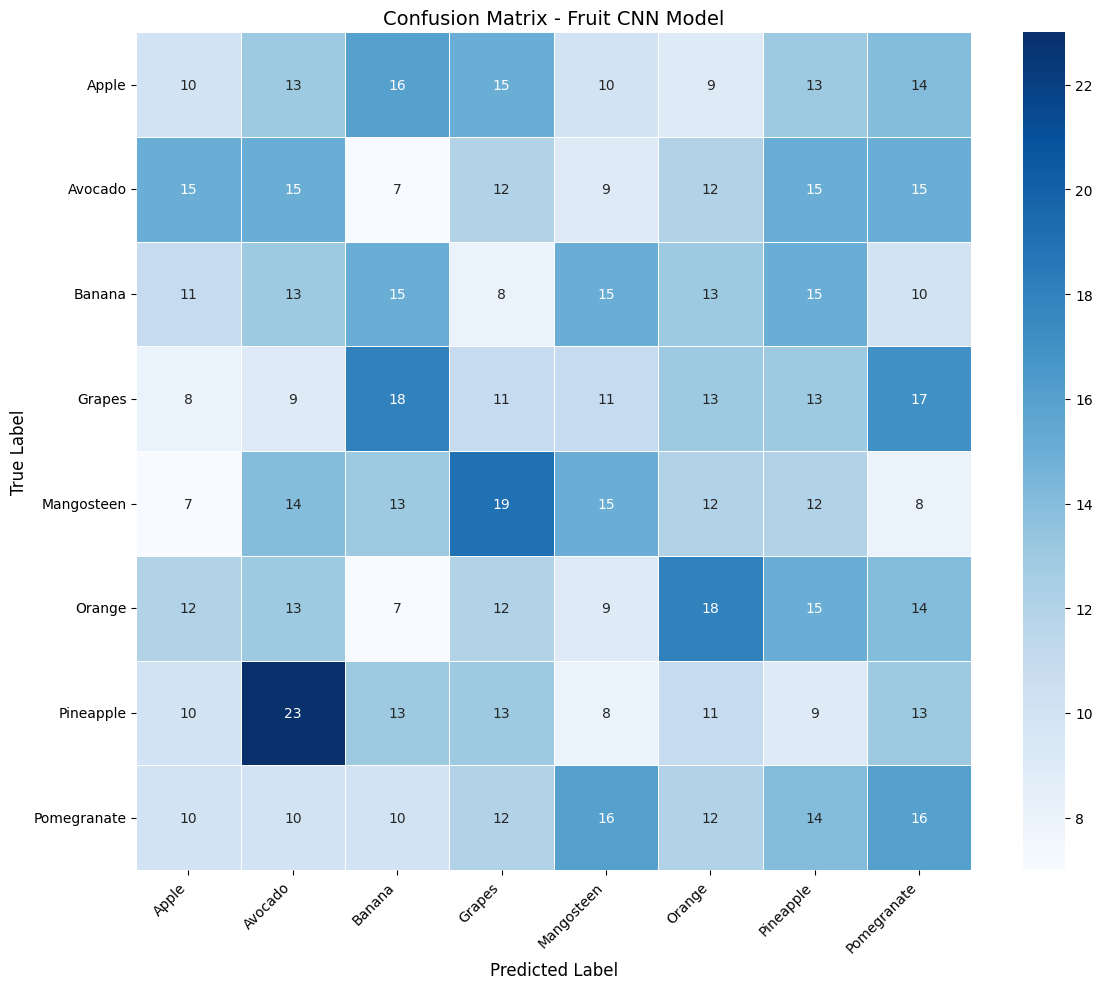

In [13]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fruit CNN Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
print('\nMost Common Misclassifications (> 10 occurrences):')
print('-' * 60)

num_classes = len(class_names)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 10:   # threshold adjustable
            print(f'  {class_names[i]:<15} misclassified as '
                  f'{class_names[j]:<15} : {cm[i,j]} times')


Most Common Misclassifications (> 10 occurrences):
------------------------------------------------------------
  Apple           misclassified as Avocado         : 13 times
  Apple           misclassified as Banana          : 16 times
  Apple           misclassified as Grapes          : 15 times
  Apple           misclassified as Pineapple       : 13 times
  Apple           misclassified as Pomegranate     : 14 times
  Avocado         misclassified as Apple           : 15 times
  Avocado         misclassified as Grapes          : 12 times
  Avocado         misclassified as Orange          : 12 times
  Avocado         misclassified as Pineapple       : 15 times
  Avocado         misclassified as Pomegranate     : 15 times
  Banana          misclassified as Apple           : 11 times
  Banana          misclassified as Avocado         : 13 times
  Banana          misclassified as Mangosteen      : 15 times
  Banana          misclassified as Orange          : 13 times
  Banana          m

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

# Load and preprocess the image
img = image.load_img(r"image.jpg", target_size=(128,128))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0

# Predict
prediction = model.predict(img_array)

# Get predicted class index
class_index = np.argmax(prediction)

# Map to class labels
class_labels = list(train_data.class_indices.keys())
predicted_class = class_labels[class_index]

# Get confidence for the predicted class
confidence = prediction[0][class_index] * 100


plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f}%)")
plt.axis("off")
plt.show()